# <center>Поправка Бонферрони (искусственные данные)<center>

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

### 1) Генерация 3-х групп данных

In [21]:
np.random.seed(36)

In [22]:
groupa = np.random.normal(loc = 2450, scale = 365, size = 1000)
groupb = np.random.normal(loc = 3500, scale = 420, size = 1000)
groupc = np.random.normal(loc = 4800, scale = 510, size = 1000)

### 2) Визуализация полученных групп

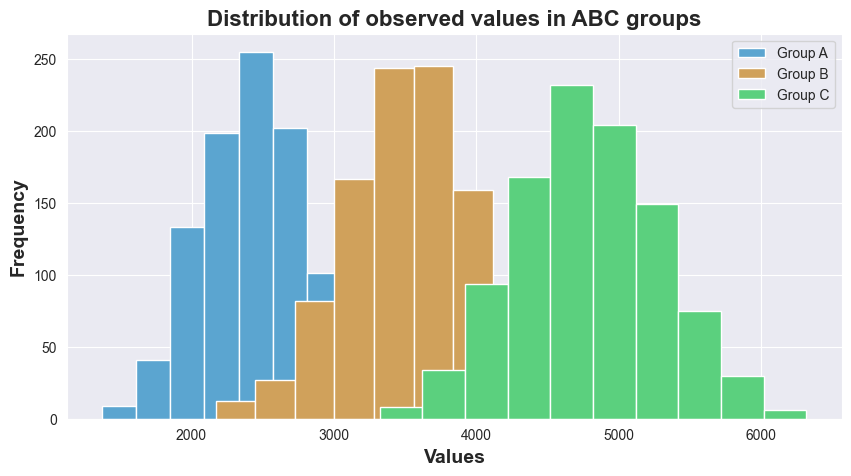

In [23]:
plt.subplots(figsize = (10,5))
sns.set_style(style = 'darkgrid')
plt.title('Distribution of observed values in ABC groups', fontsize = 16, fontweight = 'bold')
plt.xlabel('Values', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequency', fontsize = 14, fontweight = 'bold')

plt.hist(x = groupa, label = 'Group A', color = '#5BA5D0')
plt.hist(x = groupb, label = 'Group B', color = '#D0A15B')
plt.hist(x = groupc, label = 'Group C', color = '#5BD07E')

plt.legend()

### 3) Проведение парных Т-тестов

Установим **`уровень значимости`** на уровне **`5%`**. Также, учитывая, что мы проводим **`множественное сравнение`**, совершим **`коррекцию Бонферрони`**, разделив уровень значимости на количество групп

In [24]:
alpha = 0.05/3

In [25]:
statab, pab = ttest_ind(groupa, groupb)
statbc, pbc = ttest_ind(groupb, groupc)
statac, pac = ttest_ind(groupa, groupc)

pvalues = [pab, pbc, pac]

def alpha_comparison_mean(alpha, p_list):
  for i, value in enumerate(p_list):
    print(f'p-значение в группе {i + 1} = {value:.4f}')
    if value > alpha:
      print('Статистически значимых различий между средними совокупностей не обнаружено\n')
    else:
      print('Обнаружены статистически значимые различия между средними совокупностей\n')

alpha_comparison_mean(alpha, pvalues)

p-значение в группе 1 = 0.0000
Обнаружены статистически значимые различия между средними совокупностей

p-значение в группе 2 = 0.0000
Обнаружены статистически значимые различия между средними совокупностей

p-значение в группе 3 = 0.0000
Обнаружены статистически значимые различия между средними совокупностей



**`Результаты`** попарных **`t-тестов`** свидетельствуют о необходимости **`отвержения нулевой гипотезы`** о равенстве средних **во всех трех случаях**. Таким образом, мы можем сделать вывод о **наличии** **`статистически значимых`** **различий** между средними выборок.

**При проведении `А/А` тестирования** следует ожидать результатов, свидетельствующих о **`наличии систематических отклонений`** **или** **`отсутствии стабильности системы`** в ходе эксперимента